In [2]:
from dask.distributed import LocalCluster

# https://forum.access-hive.org.au/t/netcdf-not-a-valid-id-errors/389/12
cluster = LocalCluster(threads_per_worker=1)          # Fully-featured local Dask cluster
client = cluster.get_client()
client

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39601 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:39601/status,
Dashboard: http://127.0.0.1:39601/status,Workers: 56
Total threads: 56,Total memory: 1.11 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44295,Workers: 56
Dashboard: http://127.0.0.1:39601/status,Total threads: 56
Started: Just now,Total memory: 1.11 TiB
Comm: tcp://127.0.0.1:42357,Total threads: 1
Dashboard: http://127.0.0.1:44659/status,Memory: 20.25 GiB
Nanny: tcp://127.0.0.1:36867,


In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
from pathlib import Path
from string import ascii_lowercase, ascii_uppercase

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import HTML, Image, display
from scipy import stats
from cmap import Colormap


/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [4]:
def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds#.sel(plev=slice(0.1, 100))

lf = lambda x: x.stem.split('_')[1][4:]


def anomalize(ds):
    clim = ds.groupby('time.month').mean('time')
    ds_anom = (ds.groupby('time.month')-clim).groupby('time.month')
    std = ds.groupby('time.month').std('time')
    return ds_anom/std, clim, std

def process(ds, sel_var, deseasonalize=True):
    #ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
   

    ds = ds[[sel_var]].sel(time = slice('2022-01',None))/100.
    ds[sel_var].attrs['units'] = 'hPa'


    if deseasonalize:
        ds, _, _= anomalize(ds)  # deseasonalize_func(ds)

    return ds.squeeze()

In [5]:
xr.set_options(keep_attrs=True)
rootpath = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/")
infile_path =rootpath / "ht"
plt.rcParams.update({"font.size": 22})

# Dataset loading

## T U V

In [13]:
what = "ta-ua-va_2021-2025.nc"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}"))

In [14]:
ds_w = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:15:52 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [15]:
ds_wo = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_wo

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:16:11 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [16]:
dims4ave = ['lon']
sel_dict = dict(time = slice("2024-09", "2025-04"))
arr1_u = ds_w['u'].mean(dims4ave).sel(**sel_dict).sel(lat = 60, method = 'nearest').load()
arr2_u = ds_wo['u'].mean(dims4ave).sel(**sel_dict).sel(lat = 60, method = 'nearest').load()

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

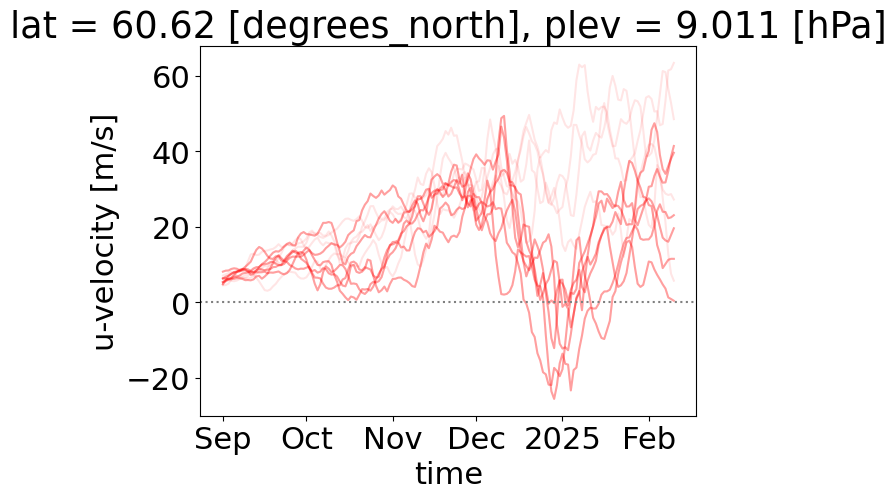

In [9]:
temp = arr1_u.sel(plev = 10, method = 'nearest').sel(time = slice(None,'2025-02-10'))
temp.plot.line(hue = 'ens', color = 'r', alpha = 0.1, add_legend = False)
mask = np.any(temp <= 0, axis = 1)
temp[mask,:].plot.line(hue = 'ens', color = 'r', alpha = 0.3, add_legend = False)
plt.axhline(0, ls = 'dotted', color = 'gray')

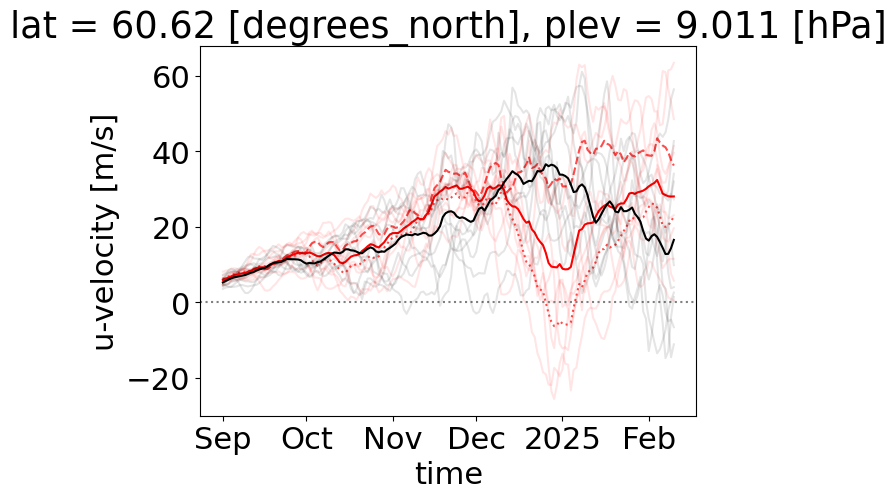

In [17]:
temp = arr1_u.sel(plev = 10, method = 'nearest').sel(time = slice(None,'2025-02-10'))
temp.plot.line(hue = 'ens', color = 'r', alpha = 0.1, add_legend = False)
temp.mean('ens').plot(color = 'r')
mask = np.any(temp.values <= 0, axis = 1)
temp[mask,:].mean('ens').plot.line(hue = 'ens', color = 'r', alpha = 0.7, add_legend = False, ls = 'dotted')
temp[~mask,:].mean('ens').plot.line(hue = 'ens', color = 'r', alpha = 0.7, add_legend = False, ls = 'dashed')
plt.axhline(0, ls = 'dotted', color = 'gray')
temp = arr2_u.sel(plev = 10, method = 'nearest').sel(time = slice(None,'2025-02-10'))
temp.plot.line(hue = 'ens', color = 'k', alpha = 0.1, add_legend = False)
temp.mean('ens').plot(color = 'k')


In [11]:
soi_w = xr.open_dataset('soi_w.nc')
soi_wo = xr.open_dataset('soi_wo.nc')

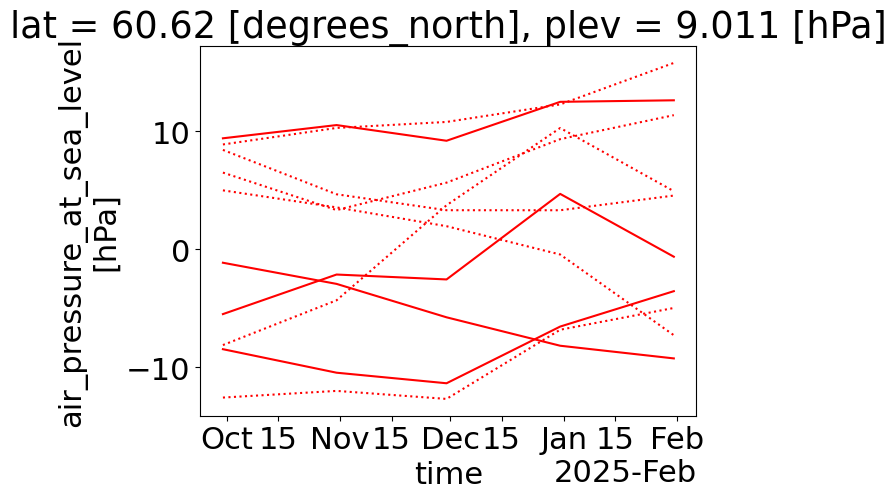

In [12]:
soi_w_sel = soi_w['psl'].sel(time = slice('2024-09','2025-02-10'))
soi_w_sel[mask,:].plot.line(hue = 'ens', add_legend = False, color = 'r', ls = 'dotted')
soi_w_sel[~mask,:].plot.line(hue = 'ens', add_legend = False, color = 'r')

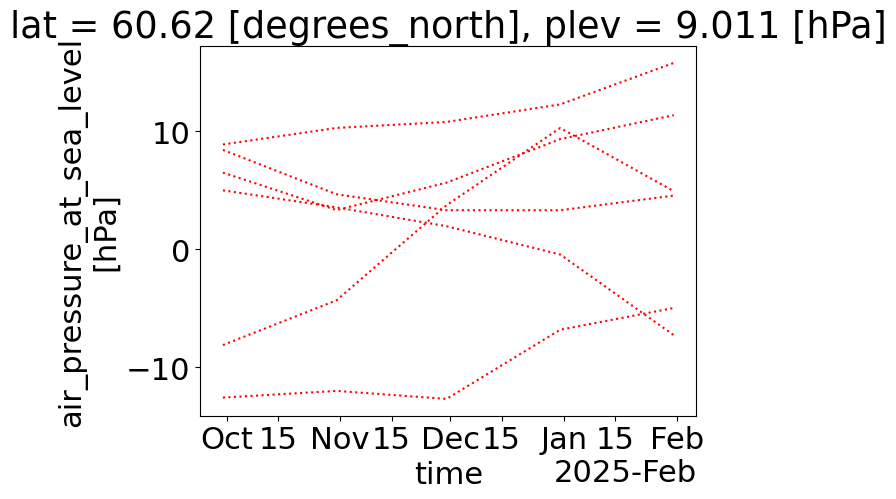

In [13]:
soi_w_sel[mask,:].plot.line(hue = 'ens', add_legend = False, color = 'r', ls = 'dotted')

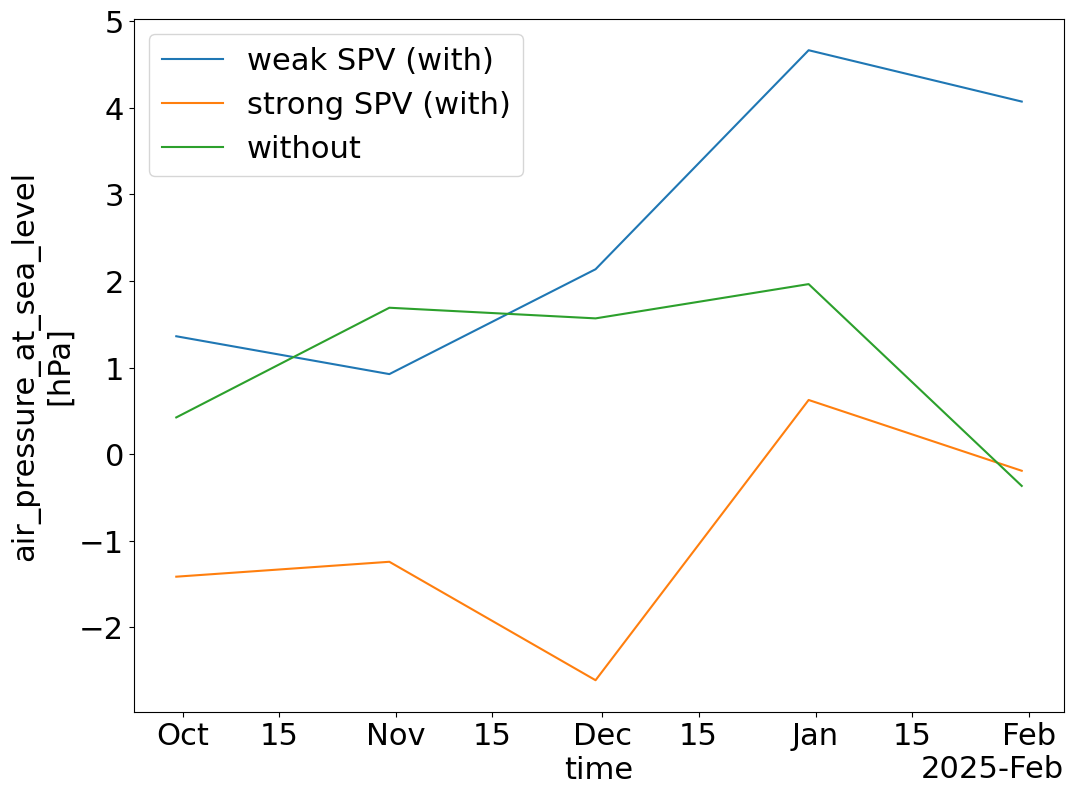

In [14]:
soi_w_sel[mask,:].mean('ens').plot(label = 'weak SPV (with)', size = 9)
soi_w_sel[~mask,:].mean('ens').plot(label = 'strong SPV (with)')
soi_wo['psl'].sel(time = slice('2024-09','2025-02-10')).mean('ens').plot(label = 'without')
plt.legend()

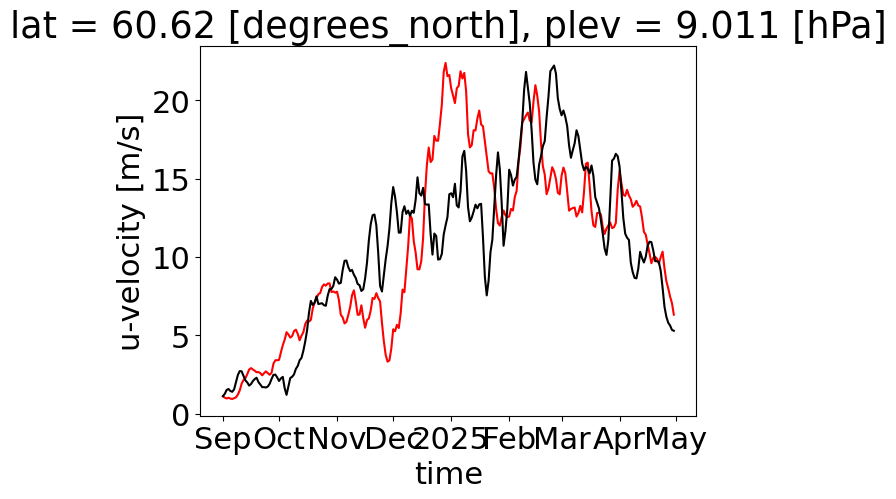

In [63]:
temp = arr1_u.sel(plev = 10, method = 'nearest')#.sel(time = slice(None,'2025-04-10'))
temp.std('ens').plot(color = 'r')

temp = arr2_u.sel(plev = 10, method = 'nearest')#.sel(time = slice(None,'2025-02-10'))
temp.std('ens').plot(color = 'k')

In [23]:
diff_u_weak = arr1_u[mask,...].mean('ens')-arr2_u.mean('ens')
diff_u_strong = arr1_u[~mask,...].mean('ens')-arr2_u.mean('ens')

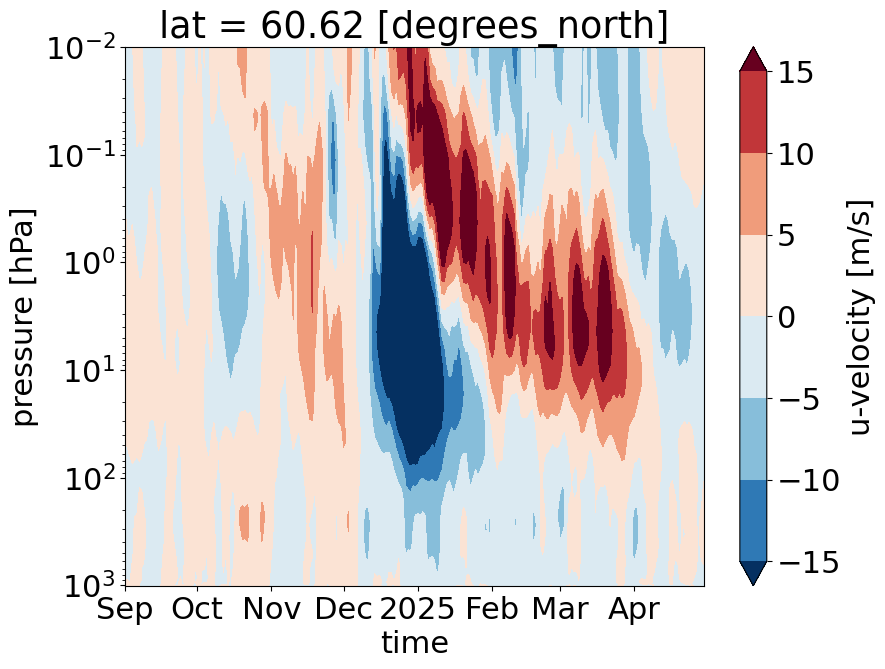

In [30]:
diff_u_weak.plot.contourf(yincrease = False, size = 7, x = 'time', vmax = 15)
plt.yscale('log')

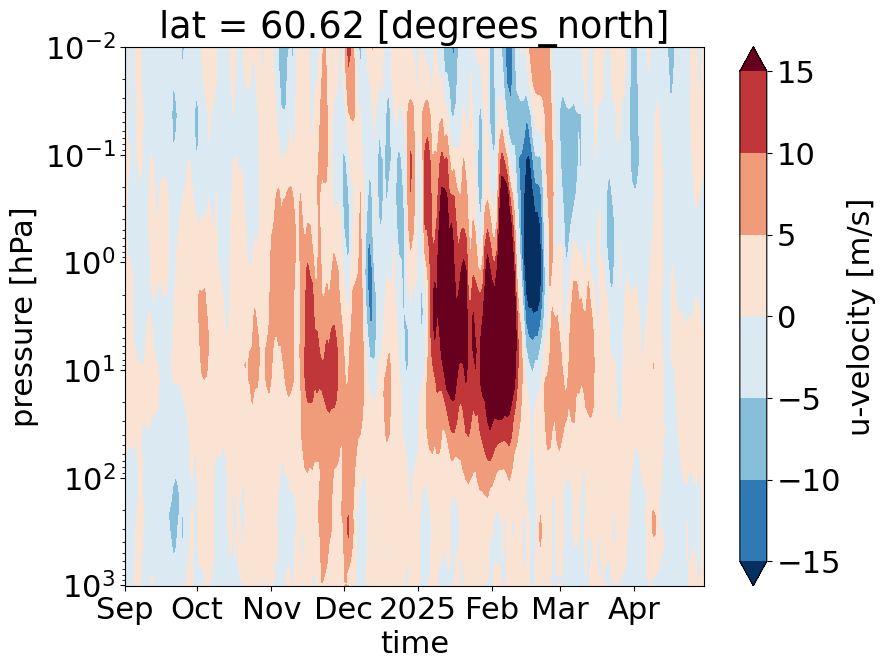

In [29]:
diff_u_strong.plot.contourf(yincrease = False, robust = True, size = 7, x = 'time')
plt.yscale('log')

In [31]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2024-09", "2025-04"))
arr1 =  ds_w['var130'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()
arr2 = ds_wo['var130'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()


diff_t_weak = arr1[mask,...].mean('ens')-arr2.mean('ens')
diff_t_strong = arr1[~mask,...].mean('ens')-arr2.mean('ens')

2025-11-11 23:59:14,610 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:35009
Traceback (most recent call last):
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/comm/tcp.py", line 227, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/comm/tcp.py", line 366, in read_bytes_rw
    actual = await stream.read_into(chunk)  # type: ignore[arg-type]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/worker.py", line 2075, in gather_dep
    response = await get_data_from_worker(
               ^^^

## WV

In [32]:
what = "H2O_m"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [33]:
time_arr = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
)['time'].values
 

In [34]:
ds_w_wv = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_wv

<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1826, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 14:43:50 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [35]:
ds_wo_wv = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_wv

<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1461, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 16:11:55 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [36]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2024-09", "2025-04"))
arr1 = ds_w_wv['H2O_m'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()*1e6
arr2 = ds_wo_wv['H2O_m'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()*1e6
#diff = arr1 - arr2
diff_wv_weak = arr1[mask,...].mean('ens')-arr2.mean('ens')
diff_wv_strong = arr1[~mask,...].mean('ens')-arr2.mean('ens')

2025-11-12 00:00:27,876 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 14.20 GiB -- Worker memory limit: 20.25 GiB
2025-11-12 00:00:36,258 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 14.19 GiB -- Worker memory limit: 20.25 GiB
2025-11-12 00:00:44,959 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. 

## EHF

In [37]:
ds_diff_2324 = xr.load_dataset('../ehf_diff_2023-09_2024-04.nc')
ds_diff_2425 = xr.load_dataset('../ehf_diff_2024-09_2025-04.nc')



## ozone

In [38]:
what = "ozone"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [39]:
ds_w_o3 = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_o3

<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:28 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [40]:
ds_wo_o3 = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_o3

<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:49 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [41]:
weights = np.cos(np.deg2rad(ds_w_o3.lat))
weights.name = "weights"

dims4ave = ['ens']
sel_dict = dict(lat = slice(None,60), time = slice("2024-09", "2025-04"))
arr1_o3 =  ds_w_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()
arr2_o3 =  ds_wo_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()

In [47]:
diff_o3_weak = arr1_o3[mask,...].mean('ens')-arr2_o3.mean('ens')
diff_o3_strong = arr1_o3[~mask,...].mean('ens')-arr2_o3.mean('ens')

# visualization

### 2024-2025

#### weak

TE+U+WV+O3_time-evolution_2024-2025_weak.pdf


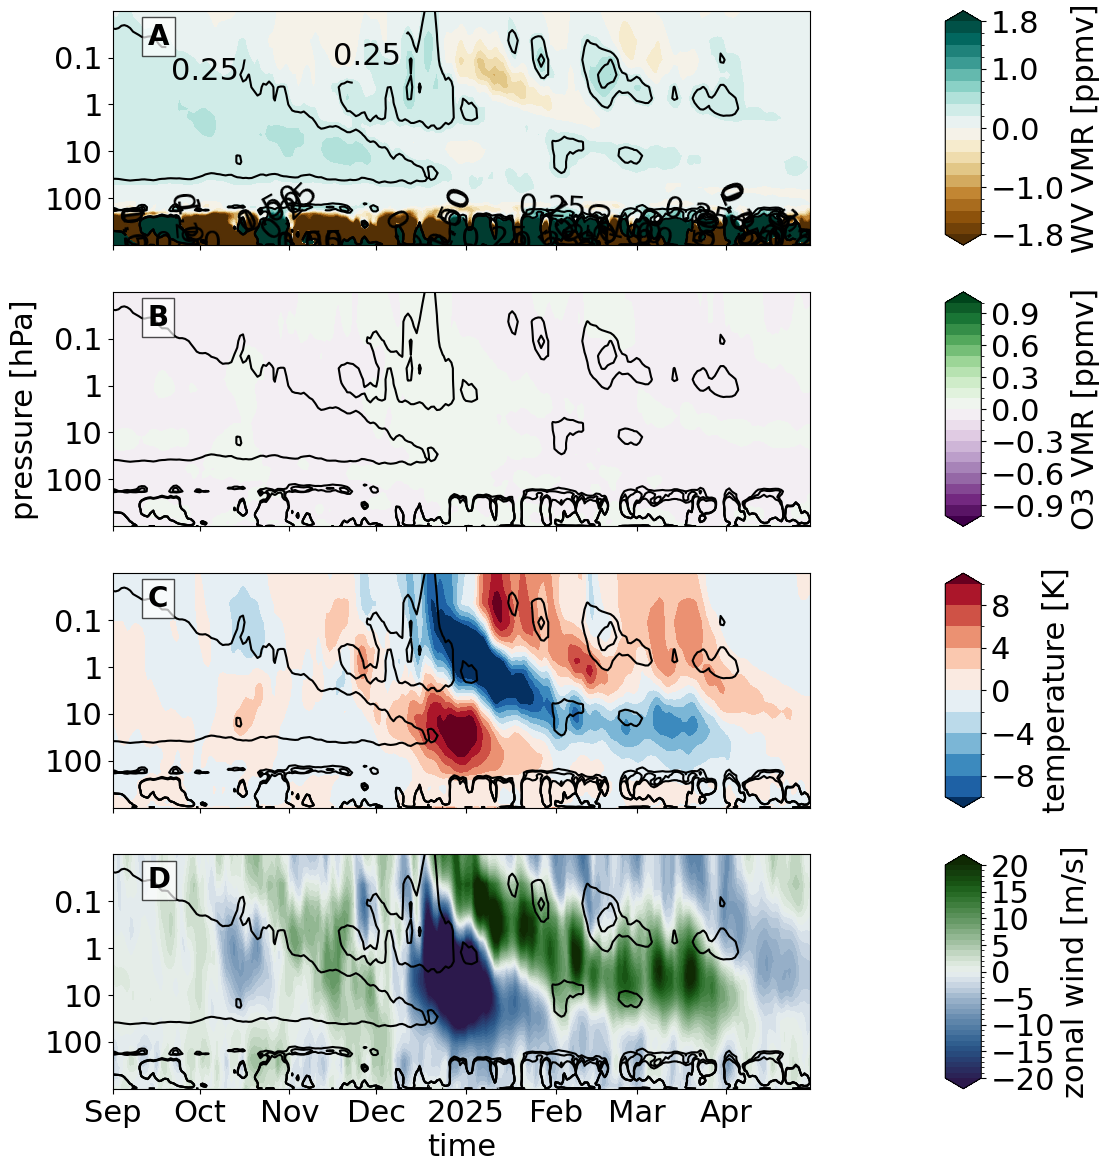

In [54]:
n_rows = 4
time_sel_dict = dict(plev = slice(0.1,200)) # time = slice("2023-09", "2024-04"),

f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_wv_weak).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    extend = 'both',     
    levels = np.arange(-1.8,2,0.2), ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
CS = (diff_wv_weak).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
ax.clabel(CS)



# ozone
ax = axes[1]
p = (diff_o3_weak.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-1,1.1,0.1),
    cmap = 'PRGn',
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)


CS = (diff_wv_weak).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

# temperature
ax = axes[2]
p = (diff_t_weak).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-10,12,2),
    ax = ax, extend='both', cmap = 'RdBu_r',
    add_colorbar = False,
)
p_ls.append(p)

CS = (diff_wv_weak).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)




# zonal wind
ax = axes[-1]
cm = Colormap('cork')  #'crameri:vik')
cmap = cm.to_matplotlib()

p2 = diff_u_weak.plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-20,21,1),
    ax = ax, extend='both',
    cmap = cmap,
    add_colorbar = False,
)
p_ls.append(p2)

CS = (diff_wv_weak).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

#ax.set_title('')

for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')


cx_shift= 0.15
label_ls = ['WV VMR [ppmv]','O3 VMR [ppmv]','temperature [K]']
ticks_ls = [[-1.8,-1,0,1,1.8],[-0.9,-0.6,-0.3,0,0.3,0.6,0.9],[-16,-12,-8,-4,0,4,8,12,16],[-2,-1,0,1,2]]
for i, label, p, ticks in zip(range(3),label_ls,p_ls, ticks_ls):
    posn = axes[i].get_position()
    cax = f.add_axes([0.1,-0.1,0.5,0.1])
    
    cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
    f.colorbar(p, cax=cax, orientation='vertical', label=label, extend = 'both', spacing = 'proportional', ticks = ticks)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
f.colorbar(p2, cax=cax, orientation='vertical', label='zonal wind [m/s]', extend = 'both', spacing = 'proportional', ticks = [-20,-15,-10,-5,0,5,10,15,20])


outfile = f"TE+U+WV+O3_time-evolution_2024-2025_weak.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

#### strong

TE+U+WV+O3_time-evolution_2024-2025_strong.pdf


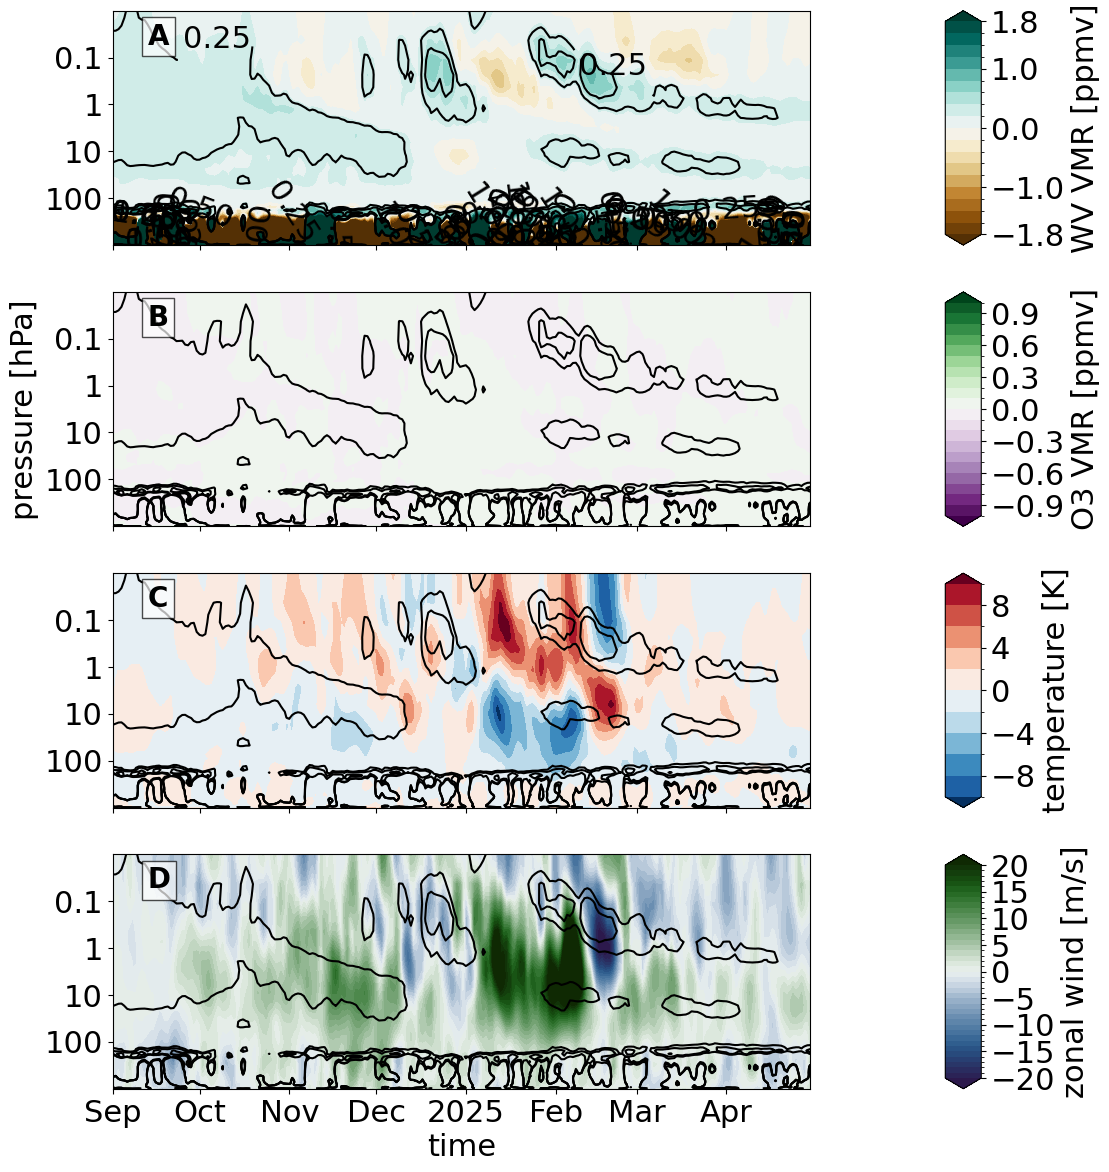

In [55]:
n_rows = 4
time_sel_dict = dict(plev = slice(0.1,200)) # time = slice("2023-09", "2024-04"),

f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_wv_strong).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    extend = 'both',     
    levels = np.arange(-1.8,2,0.2), ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
CS = (diff_wv_strong).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
ax.clabel(CS)



# ozone
ax = axes[1]
p = (diff_o3_strong.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-1,1.1,0.1),
    cmap = 'PRGn',
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)


CS = (diff_wv_strong).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

# temperature
ax = axes[2]
p = (diff_t_strong).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-10,12,2),
    ax = ax, extend='both', cmap = 'RdBu_r',
    add_colorbar = False,
)
p_ls.append(p)

CS = (diff_wv_strong).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)




# zonal wind
ax = axes[-1]
cm = Colormap('cork')  #'crameri:vik')
cmap = cm.to_matplotlib()

p2 = diff_u_strong.plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-20,21,1),
    ax = ax, extend='both',
    cmap = cmap,
    add_colorbar = False,
)
p_ls.append(p2)

CS = (diff_wv_strong).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

#ax.set_title('')

for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')


cx_shift= 0.15
label_ls = ['WV VMR [ppmv]','O3 VMR [ppmv]','temperature [K]']
ticks_ls = [[-1.8,-1,0,1,1.8],[-0.9,-0.6,-0.3,0,0.3,0.6,0.9],[-16,-12,-8,-4,0,4,8,12,16],[-2,-1,0,1,2]]
for i, label, p, ticks in zip(range(3),label_ls,p_ls, ticks_ls):
    posn = axes[i].get_position()
    cax = f.add_axes([0.1,-0.1,0.5,0.1])
    
    cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
    f.colorbar(p, cax=cax, orientation='vertical', label=label, extend = 'both', spacing = 'proportional', ticks = ticks)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
f.colorbar(p2, cax=cax, orientation='vertical', label='zonal wind [m/s]', extend = 'both', spacing = 'proportional', ticks = [-20,-15,-10,-5,0,5,10,15,20])


outfile = f"TE+U+WV+O3_time-evolution_2024-2025_strong.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

### SLP composite

In [6]:
what = "slp_mm"
infiles_w = sorted(infile_path.glob(f"socol4_htt1*{what}*2025.nc"))
infiles_wo = sorted(infile_path.glob(f"socol4_htt2*{what}*2025.nc"))
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_slp_mm_2021-2025.nc')]

In [7]:
ds_w = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    #chunks = {'plev':1},
    concat_dim=["ens"],
    #data_vars='minimal', coords='minimal', compat='override'
).pipe(process, 'psl', deseasonalize=False)
ds_w['ens'] = list(map(lf, infiles_w))
ds_w

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 35MB
Dimensions:  (time: 48, lon: 192, lat: 96, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 384B 2022-01-31 2022-02-28 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
Data variables:
    psl      (ens, time, lat, lon) float32 35MB dask.array<chunksize=(1, 48, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    frequency:    mon
    history:      Thu May 09 21:43:44 2024: cdo cat Postproc_example-slp-para...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [8]:
ds_wo = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    #chunks = {'plev':1},
    concat_dim=["ens"],
    #data_vars='minimal', coords='minimal', compat='override'
).pipe(process, 'psl', deseasonalize=False)
ds_wo['ens'] = list(map(lf, infiles_wo))
ds_wo

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 35MB
Dimensions:  (time: 48, lon: 192, lat: 96, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 384B 2022-01-31 2022-02-28 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
Data variables:
    psl      (ens, time, lat, lon) float32 35MB dask.array<chunksize=(1, 48, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    frequency:    mon
    history:      Thu May 09 21:43:49 2024: cdo cat Postproc_example-slp-para...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

#### 2023-2024

In [10]:
psl_w = ds_w['psl'].sel(time = slice('2023-12','2024-02'))
psl_wo = ds_wo['psl'].sel(time = slice('2023-12','2024-02')).mean(['ens'])
diff_psl = psl_w.mean('ens')-psl_wo

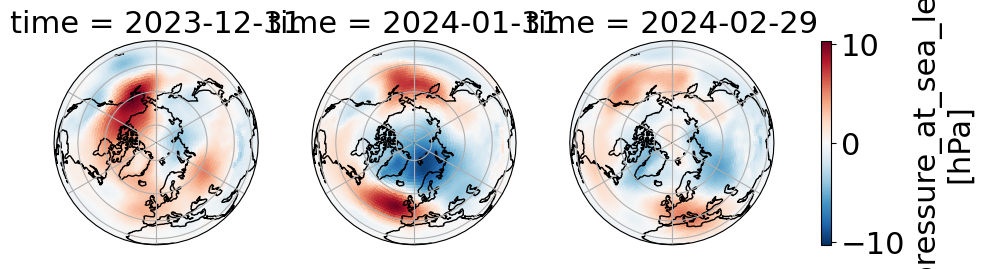

In [86]:
p = diff_psl_weak.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(0, 90), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    col = 'time'
)
for ax in p.axs.flat:
    ax.coastlines()
    ax.gridlines()

#### 2024-2025

In [11]:
#sel_dict = dict(time = slice('2024-12','2025-02'))
sel_dict = dict(time ='2025-02')
psl_w = ds_w['psl'].sel(**sel_dict).mean('time')
psl_wo = ds_wo['psl'].sel(**sel_dict).mean('time')


In [18]:
psl_w_weak = psl_w[mask,...].mean(['ens'])
psl_w_strong = psl_w[~mask,...].mean(['ens'])
diff_psl_weak = psl_w_weak-psl_wo.mean(['ens'])
diff_psl_strong = psl_w_strong-psl_wo.mean(['ens'])

In [19]:
t_stat, p_values = stats.ttest_ind(
    psl_w[mask,...], psl_wo, equal_var=False
)  # , nan_policy = nan_policy)
diff_pv = xr.DataArray(p_values, coords=diff_psl_weak.coords)
diff_pv
#diff_pv_fdr = xr_multipletest(diff_pv)[1]

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


<xarray.DataArray (lat: 96, lon: 192)> Size: 74kB
array([[0.42961586, 0.42978364, 0.43004298, ..., 0.4296781 , 0.42956656,
        0.42956033],
       [0.32109386, 0.32263312, 0.32456225, ..., 0.31885052, 0.31917647,
        0.3199238 ],
       [0.21546566, 0.21664327, 0.21870421, ..., 0.21801037, 0.21606737,
        0.21524698],
       ...,
       [0.742111  , 0.7435996 , 0.74489874, ..., 0.7364233 , 0.7384753 ,
        0.74046504],
       [0.72398645, 0.7278357 , 0.73197   , ..., 0.7144469 , 0.7172614 ,
        0.7204811 ],
       [0.9045    , 0.90191865, 0.89906794, ..., 0.9100316 , 0.90849817,
        0.90663356]], dtype=float32)
Coordinates:
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1

(array([101.,  87., 140., 245., 342., 635., 653., 725.,  71.,   0.]),
 array([ 999.2331543 , 1002.29077148, 1005.34844971, 1008.40606689,
        1011.46374512, 1014.5213623 , 1017.57897949, 1020.63665771,
        1023.6942749 , 1026.75195312, 1029.80957031]),
 <BarContainer object of 10 artists>)

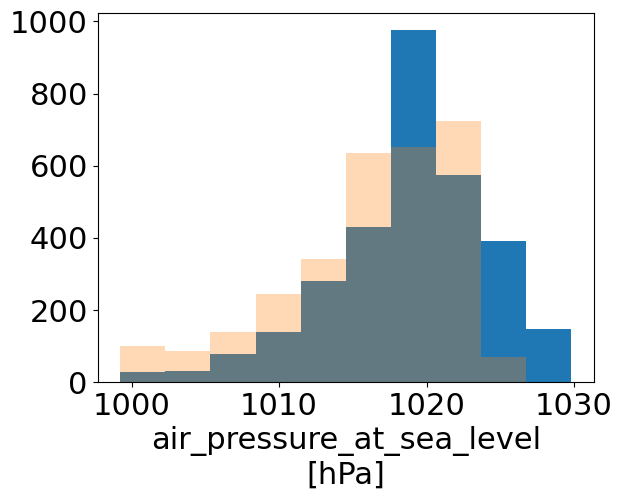

In [133]:
bins = psl_w[mask,...].sel(lat = slice(None,60)).mean('ens').plot.hist()
psl_wo.sel(lat = slice(None,60)).mean('ens').plot.hist(bins = bins[1], alpha = 0.3)

##### weak

(array([  238.,   404.,   545.,  2919.,  3430., 10896.]),
 array([0.  , 0.01, 0.05, 0.1 , 0.3 , 0.5 , 1.  ]),
 <BarContainer object of 6 artists>)

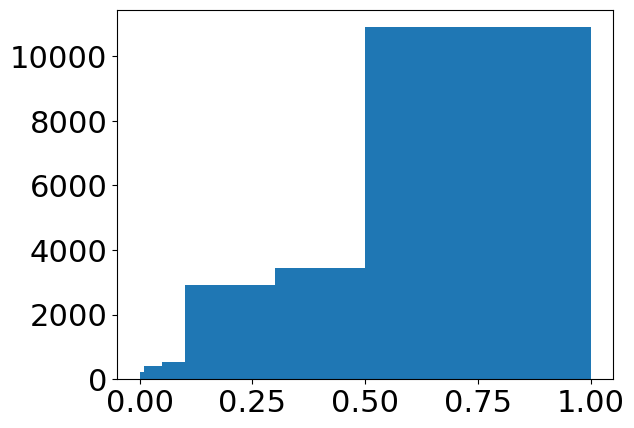

In [134]:
diff_pv.plot.hist(bins = [0,0.01,0.05,0.1,0.3,0.5,1])

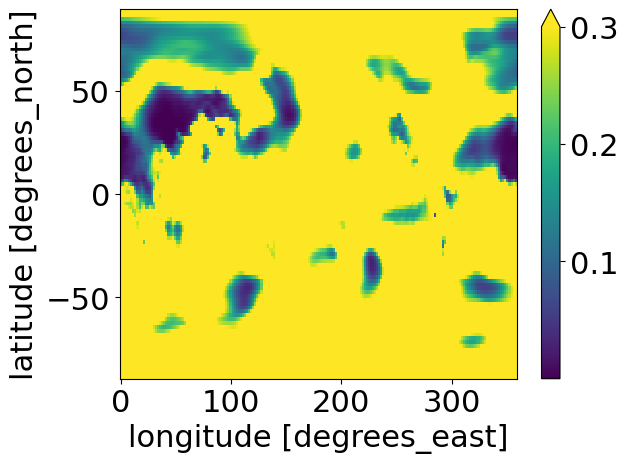

In [135]:
diff_pv.plot(vmax = 0.3)

In [25]:
p.colorbar.vmax

7.726706542968751

In [20]:
diff_psl_weak

<xarray.DataArray 'psl' (lat: 96, lon: 192)> Size: 74kB
dask.array<sub, shape=(96, 192), dtype=float32, chunksize=(96, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Attributes:
    standard_name:     air_pressure_at_sea_level
    units:             hPa
    code:              151
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    cell_methods:      time: mean

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

SLP_map_cluster_2025_Feb.pdf


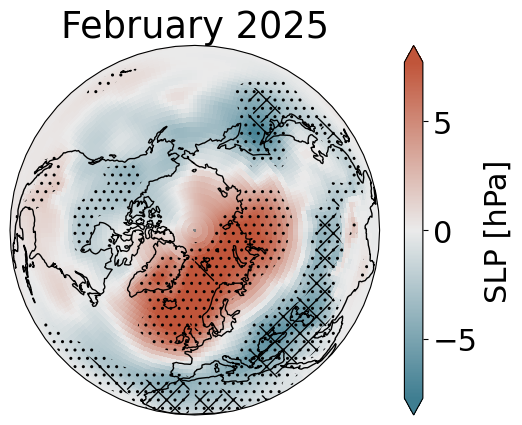

In [21]:
cm = Colormap("vispy:RdBu_r")  #'crameri:vik')

p = diff_psl_weak.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(0, 90), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    cbar_kwargs = dict(label = 'SLP [hPa]'),
    cmap=cm.to_matplotlib(),
    extend = 'both',
    robust = True,
)

ax = p.axes

kwargs = dict(
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",  # "//",
        None,
    ],
    transform=ccrs.PlateCarree()
    # linewidths=np.linspace(1, 4, 4),
)

p.data = diff_pv
diff_pv.plot.contourf(ax=ax, **kwargs)

kwargs["levels"] = [0, 0.1]
kwargs["hatches"] = ["\\", None]
diff_pv.plot.contourf(ax=ax, **kwargs)

kwargs["levels"] = [0, 0.3]
kwargs["hatches"] = ["..", None]
diff_pv.plot.contourf(ax=ax, **kwargs)

ax.set_title('February 2025')
ax.set_global()

ax.coastlines()

outfile = f"SLP_map_cluster_2025_Feb.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [22]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [23]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

In [127]:
psl_w = ds_w['psl'].sel(time = slice('2024-12','2025-02'))
psl_wo = ds_wo['psl'].sel(time = slice('2024-12','2025-02')).mean(['ens'])


In [128]:
psl_w_weak = psl_w[mask,...].mean(['ens'])
psl_w_strong = psl_w[~mask,...].mean(['ens'])
diff_psl_weak = psl_w_weak-psl_wo
diff_psl_strong = psl_w_strong-psl_wo

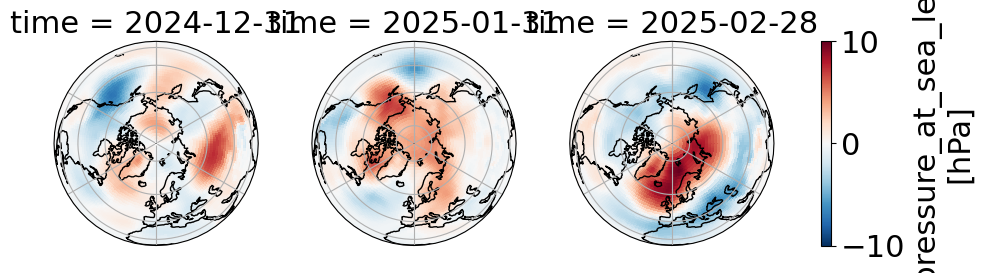

In [129]:
p = diff_psl_weak.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(0, 90), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    col = 'time'
)
for ax in p.axs.flat:
    ax.coastlines()
    ax.gridlines()

##### strong

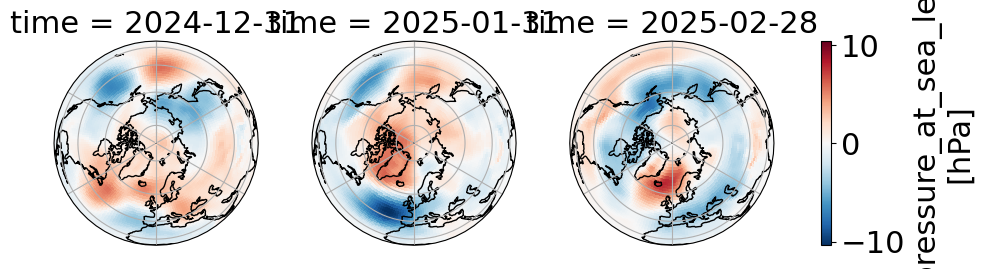

In [80]:
p = diff_psl_strong.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(0, 90), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    col = 'time'
)
for ax in p.axs.flat:
    ax.coastlines()
    ax.gridlines()